# 01 — Titanic EDA and Cleaning

This notebook is the first half of the analytics pipeline. It loads the raw Titanic dataset exactly once, saves the immediate offline fallback, profiles missingness, performs defensible cleaning, tells a visual survival story, and saves the cleaned dataset for the modeling notebook.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != "analytics":
    ROOT = ROOT / "analytics"

CSV_PATH = ROOT / "titanic.csv"
sns.set_theme(style="whitegrid")

## 1. Load once, profile, and save the offline fallback

The required online/cache loader is attempted exactly once. Immediately afterward, the loaded frame is written to `titanic.csv`. If the environment cannot reach the Seaborn repository, the already-committed CSV is used as the grading fallback.

In [2]:
try:
    df = sns.load_dataset("titanic")
    load_source = "sns.load_dataset('titanic')"
except Exception as exc:
    print("Online/cache load unavailable; using committed offline fallback:", exc)
    df = pd.read_csv(CSV_PATH)
    load_source = "committed titanic.csv fallback"

# Immediate fallback snapshot of the loaded dataset.
df.to_csv(CSV_PATH, index=False)

print("Load source:", load_source)
print("Shape:", df.shape)
display(df.head())

df.info()
display(df.describe(include="all").T)

Load source: sns.load_dataset('titanic')
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Missing-value percentages:")
display(missing_pct.to_frame("missing_percent"))

Missing-value percentages:


,missing_percent
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


## 2. Cleaning decisions

The exact measured percentages above determine the strategy. For the exploratory cleaned frame:

- Columns with less than 5% missing values have affected rows dropped.
- Columns from 5% through 30% are imputed.
- A column above 30% is retained only when missingness itself is informative or it is needed for the requested analysis; otherwise it is dropped.
- `deck` has very high missingness in the classic dataset, so it is treated as an explicit `"missing"` category for the categorical EDA representation rather than inventing a deck assignment.
- The modeling notebook independently performs train-only preprocessing, so these EDA transformations do not leak into modeling.

In [4]:
eda = df.copy()

# Required percentage-driven handling.
for col in ["embarked"]:
    if col in eda.columns:
        rate = eda[col].isna().mean() * 100
        if rate < 5:
            eda = eda.dropna(subset=[col])
        elif rate <= 30:
            eda[col] = eda[col].fillna(eda[col].mode(dropna=True).iloc[0])

# Age is around the 5–30% band, so median imputation is used for the EDA frame.
if "age" in eda.columns:
    rate = eda["age"].isna().mean() * 100
    if 5 <= rate <= 30:
        eda["age"] = eda["age"].fillna(eda["age"].median())
    elif rate < 5:
        eda = eda.dropna(subset=["age"])

# Deck has very high missingness; preserve missingness explicitly as a category.
if "deck" in eda.columns:
    deck_rate = eda["deck"].isna().mean() * 100
    if deck_rate > 30:
        eda["deck"] = eda["deck"].astype("object").fillna("missing")

# Any other low-missing columns are handled conservatively.
for col in eda.columns:
    if eda[col].isna().any():
        rate = eda[col].isna().mean() * 100
        if rate < 5:
            eda = eda.dropna(subset=[col])
        elif rate <= 30:
            if pd.api.types.is_numeric_dtype(eda[col]):
                eda[col] = eda[col].fillna(eda[col].median())
            else:
                eda[col] = eda[col].fillna(eda[col].mode(dropna=True).iloc[0])
        else:
            if not pd.api.types.is_numeric_dtype(eda[col]):
                eda[col] = eda[col].fillna("missing")

print("EDA frame shape:", eda.shape)

EDA frame shape: (889, 15)


## 3. Univariate analysis — age and fare

The outlier rule is exactly:

`[Q1 - 1.5 × IQR, Q3 + 1.5 × IQR]`.

The fare distribution is classified from the ordering of mean, median and mode rather than from the visual alone.

In [5]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return int(mask.sum()), q1, q3, low, high

for col in ["age", "fare"]:
    count, q1, q3, low, high = iqr_outlier_count(eda[col].dropna())
    print(f"{col}: outliers={count}, Q1={q1:.3f}, Q3={q3:.3f}, bounds=({low:.3f}, {high:.3f})")

fare_mean = eda["fare"].mean()
fare_median = eda["fare"].median()
fare_mode = eda["fare"].mode().iloc[0]
print(f"Fare mean={fare_mean:.3f}; median={fare_median:.3f}; mode={fare_mode:.3f}")
if fare_mean > fare_median > fare_mode:
    print("Fare interpretation: right-skewed, because mean > median > mode.")
elif fare_mean < fare_median < fare_mode:
    print("Fare interpretation: left-skewed, because mean < median < mode.")
else:
    print("Fare interpretation: the mean/median/mode ordering is not strictly monotonic; inspect the histogram as well.")

age: outliers=65, Q1=22.000, Q3=35.000, bounds=(2.500, 54.500)
fare: outliers=114, Q1=7.896, Q3=31.000, bounds=(-26.761, 65.656)
Fare mean=32.097; median=14.454; mode=8.050
Fare interpretation: right-skewed, because mean > median > mode.


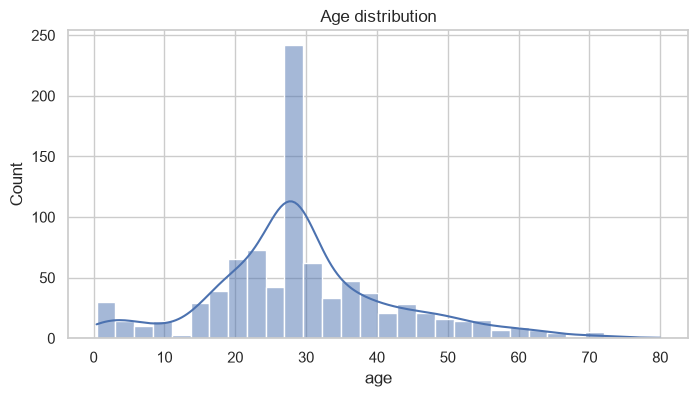

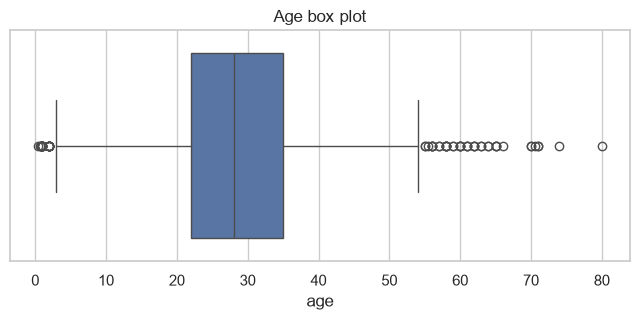

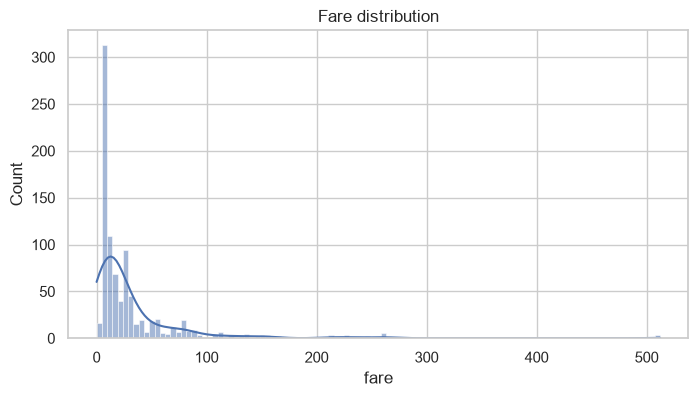

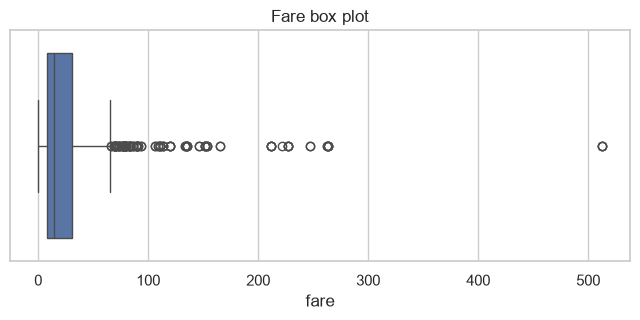

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(eda["age"], kde=True, ax=ax)
ax.set_title("Age distribution")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=eda["age"], ax=ax)
ax.set_title("Age box plot")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(eda["fare"], kde=True, ax=ax)
ax.set_title("Fare distribution")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=eda["fare"], ax=ax)
ax.set_title("Fare box plot")
plt.show()

**Univariate interpretation.** Age is concentrated around younger and middle-aged passengers, with the box plot making unusually distant ages visible under the IQR rule. Fare is much more unevenly distributed, with a long upper tail created by expensive tickets. The numerical mean/median/mode comparison above provides the stated skewness conclusion.

## 4. Bivariate survival analysis

In [7]:
def survival_rate(mask):
    subset = eda.loc[mask, "survived"]
    return float(subset.mean()) if len(subset) else np.nan

sex_rates = eda.groupby("sex")["survived"].mean().sort_index()
pclass_rates = eda.groupby("pclass")["survived"].mean().sort_index()
sex_class_rates = eda.groupby(["sex", "pclass"])["survived"].mean()

print("Survival rate by sex:")
display(sex_rates.to_frame("survival_rate"))

print("Survival rate by pclass:")
display(pclass_rates.to_frame("survival_rate"))

print("Survival rate by sex and pclass:")
display(sex_class_rates.to_frame("survival_rate"))

Survival rate by sex:


,survival_rate
sex,
female,0.740385
male,0.188908


Survival rate by pclass:


,survival_rate
pclass,
1,0.626168
2,0.472826
3,0.242363


Survival rate by sex and pclass:


survival_rate
sex    pclass               
female 1            0.967391
       2            0.921053
       3            0.500000
male   1            0.368852
       2            0.157407
       3            0.135447

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


Two strongest absolute off-diagonal correlations:
pclass vs fare: r=-0.548, |r|=0.548
sibsp vs parch: r=0.415, |r|=0.415


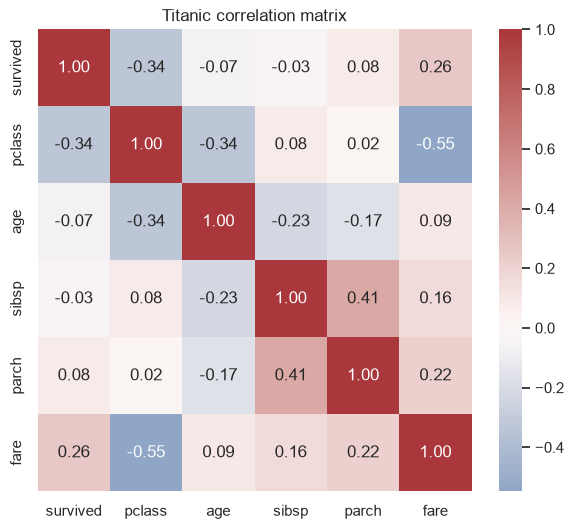

In [8]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = eda[corr_cols].corr()
display(corr)

pairs = []
for i, left in enumerate(corr_cols):
    for right in corr_cols[i+1:]:
        pairs.append((abs(corr.loc[left, right]), corr.loc[left, right], left, right))
top_two = sorted(pairs, reverse=True)[:2]
print("Two strongest absolute off-diagonal correlations:")
for abs_value, signed_value, left, right in top_two:
    print(f"{left} vs {right}: r={signed_value:.3f}, |r|={abs_value:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Titanic correlation matrix")
plt.show()

**Correlation interpretation.** The two pairs printed above are selected mechanically by ranking all off-diagonal coefficients by absolute value, so no subjective pair selection is being made. The sign indicates whether the variables move together or in opposite directions, while the magnitude indicates the strength of the linear association in this dataset.

## 5. Multivariate data story

Each chart below has its own interpretation. Together they examine survival through sex, passenger class, age/fare, and their interactions.

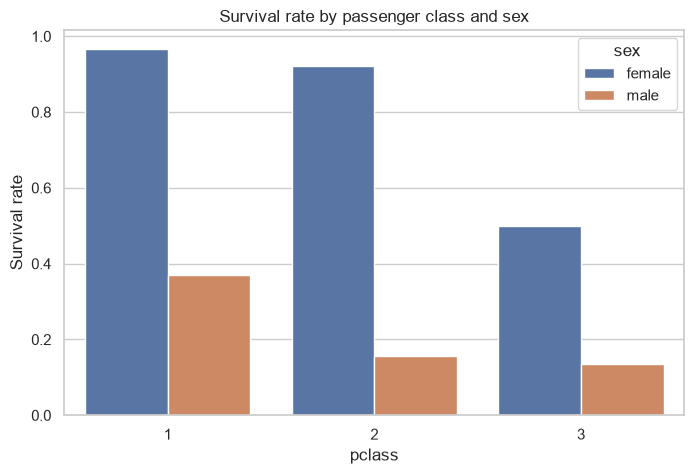

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=eda, x="pclass", y="survived", hue="sex", errorbar=None, ax=ax)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by passenger class and sex")
plt.show()

**Chart interpretation 1.** Survival varies across passenger classes, and the sex breakdown shows that class alone does not explain the observed differences. The interaction is useful because it reveals whether the class pattern is similar for the two sex groups.

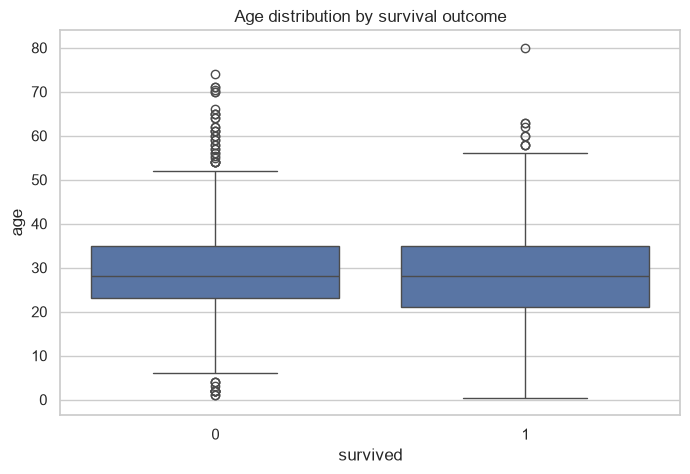

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=eda, x="survived", y="age", ax=ax)
ax.set_title("Age distribution by survival outcome")
plt.show()

**Chart interpretation 2.** The age distributions overlap substantially, so age is not a complete separator of survivors and non-survivors. Differences in medians and spread are still useful as one component of a multivariate explanation.

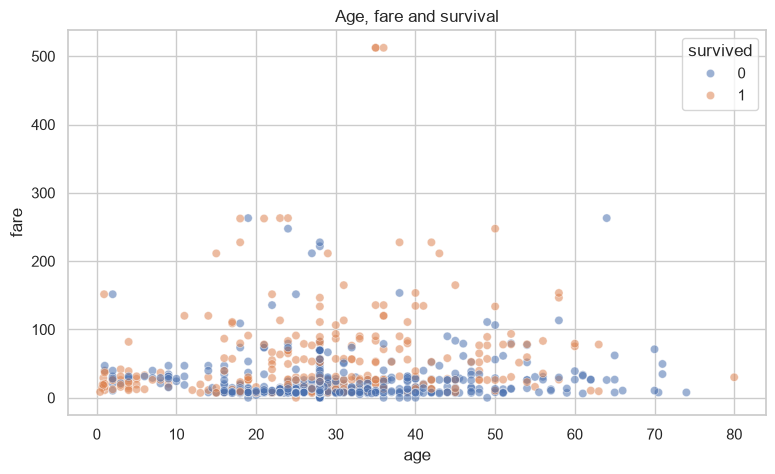

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=eda, x="age", y="fare", hue="survived", alpha=0.55, ax=ax)
ax.set_title("Age, fare and survival")
plt.show()

**Chart interpretation 3.** The scatter shows that survival is distributed across a broad range of ages and fares, but high-fare observations are concentrated in particular passenger groups. This supports treating fare as a proxy for travel circumstances rather than interpreting it as a standalone causal variable.

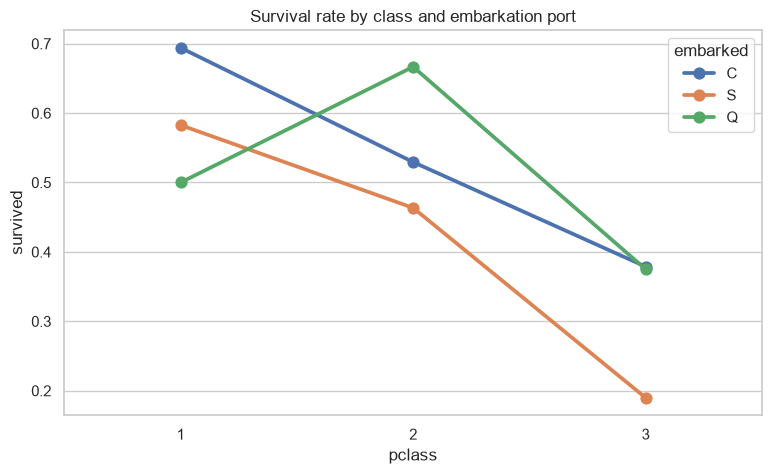

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(data=eda, x="pclass", y="survived", hue="embarked", errorbar=None, ax=ax)
ax.set_title("Survival rate by class and embarkation port")
plt.show()

**Chart interpretation 4.** Survival rates differ across class and embarkation groups, showing that passenger characteristics interact rather than forming a single one-dimensional ranking. This is one reason the predictive stage uses several features jointly.

## 6. Exploratory standardization sanity check

This standardization is intentionally **not** reused by the modeling pipeline. The modeling notebook fits its own scaler on the training fold only.

In [13]:
standardized = eda[["age", "fare"]].copy()
for col in standardized.columns:
    standardized[col] = (standardized[col] - standardized[col].mean()) / standardized[col].std()

comparison = pd.DataFrame({
    "before_mean": eda[["age", "fare"]].mean(),
    "before_std": eda[["age", "fare"]].std(),
    "after_mean": standardized.mean(),
    "after_std": standardized.std(),
})
display(comparison)

print("Approximate zero means and unit sample standard deviations confirm the z-score transformation.")

,before_mean,before_std,after_mean,after_std
age,29.315152,12.984932,2.797412e-16,1.0
fare,32.096681,49.697504,1.358743e-16,1.0


Approximate zero means and unit sample standard deviations confirm the z-score transformation.


## 7. Save the cleaned EDA frame

The modeling notebook starts from the committed offline dataset rather than from this exploratory object. The cleaned frame is nevertheless saved as a reproducibility artifact for inspection.

In [14]:
cleaned_path = ROOT / "titanic_cleaned_eda.csv"
eda.to_csv(cleaned_path, index=False)
print("Saved:", cleaned_path)

Saved: C:\Users\lkunc\Documents\capstone-project\analytics\titanic_cleaned_eda.csv
